In [1]:
%load_ext autoreload
%autoreload 2

In [12]:
import numpy as np
import branes, individual
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from sklearn.decomposition import PCA
import glob
import os
from scipy.stats import skellam

In [3]:
plt.style.use(['science', 'dark_background', 'bright'])

# Intersecting branes
Consistent intersecting brane models on an orientifold of $\mathbb{T}^6/(\mathbb{Z}_2\times\mathbb{Z}_2)$ are found using a genetic algorithm.

## Running the genetic algorithm
Set all parameters for the genetic algorithm and run.

In [20]:
# Environment parameters
env = 1
bix2 = [0, 0, 0]
UI = [1, 1, 1, 2]
kMin = 2
kMax = 10
envParams = [env, bix2, UI, kMin, kMax]

# GA meta-parameters
nRuns = 5
gMax = 100
nPop = 250
nElite = 20
GAmetaParams = [nRuns, gMax, nPop, nElite]

# Cross-over probabilities for the four methods,
#    [stack, stackBAR, gene, geneBAR]
xoverProbs = [0.25, 0.25, 0.25, 0.25]

# Mutation rates
mutRates = [0.5,   # split
            0.01,  # permute stacks
            0.5,   # N
            0.3,   # w
            0.01,   # sgns
            0.1    # S4
           ]

# Fitness parameters
weights = [0.4, 0.05, 0.55, 0]
tadScale = 64
susyScale = 0.5
fitnessParams = [weights, tadScale, susyScale]

# Other
displayRun = True
saveTKS = False

branes.GA(envParams, GAmetaParams, xoverProbs, mutRates, fitnessParams, displayRun, saveTKS, '')

Starting run 1...


KeyboardInterrupt: 

## Statistics
Previously found models are loaded and analyzed.

In [592]:
# Load files containing models of interest
files = glob.glob('models_test/*/*/KS_*.npy')
modelData = [np.load(f) for f in files]

# Extract info about environment/run from filepaths
bix2Data = [[int(b) for b in f.split('\\')[1].split(' ')[1:]] for f in files]
UIData = [[int(U) for U in f.split('\\')[2].split(' ')[1:]] for f in files]
metaData = np.array([f.split('\\')[-1].split('_') for f in files])

# Flatten all arrays and extract metaData
kList = np.empty(0, dtype='int')
envList = np.empty(0, dtype='int')
bix2List = np.empty([0, 3], dtype='int')
UIList = np.empty([0, 4], dtype='int')

for i in range(len(modelData)):
    ones = np.ones(len(modelData[i]), dtype='int')
    
    kList = np.append(kList, int(metaData[i,1][2:]) * ones)
    envList = np.append(envList, int(metaData[i,2][4:]) * ones)
    bix2List = np.append(bix2List, np.outer(ones, bix2Data[i]), axis=0)
    UIList = np.append(UIList, np.outer(ones, UIData[i]), axis=0)
    
models = [a for b in modelData for a in b]

In [500]:
# Compute characteristics of all models
maxSUN = 5
info = np.array([individual.getInfo(models[i], envList[i], bix2List[i], UIList[i], fitnessParams, maxSUN)
                 for i in range(len(models))])

tadnorms = info[:,0]
ranks = info[:,2]
ABCcounts = np.concatenate(info[:,3]).reshape(len(models), 3)
SUNcounts = np.concatenate(info[:,4]).reshape(len(models), maxSUN+1)

### Winding number pairs

In [502]:
nmMax = 8
nmPairs = np.zeros([nmMax+1, nmMax+1], dtype='int')

for chrome in models:
    for stack in chrome:
        for ii in range(3):
            n, m = np.sort([abs(stack[2*ii+1]), abs(stack[2*ii+2])])
            if m <= nmMax:
                nmPairs[n,m] += 1

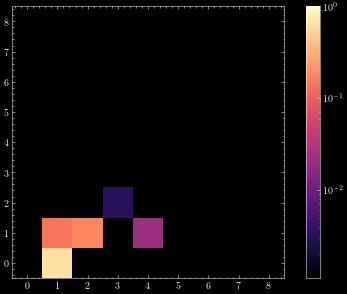

In [541]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
im = ax.matshow(nmPairs/np.sum(nmPairs), origin='lower', cmap='magma', norm=colors.LogNorm(vmax=1))
plt.colorbar(im)
plt.tick_params(axis='x', labelbottom=True, labeltop=False)
plt.show()

### $\mathrm{SU}(N)$ factors

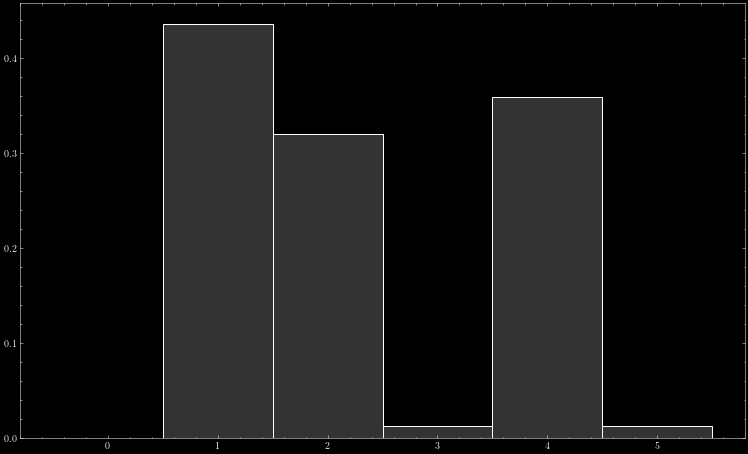

In [528]:
SUNtotals = np.sum(SUNcounts, axis=0)
SUNprobs = [np.mean(SUNcounts[:, n] > 0) for n in range(maxSUN + 1)]

fig, ax = plt.subplots(1, 1, figsize=(13,8))
plt.bar(range(len(SUNprobs)), SUNprobs, width=1, color='0.2', edgecolor='w')
plt.show()

### Tadpoles

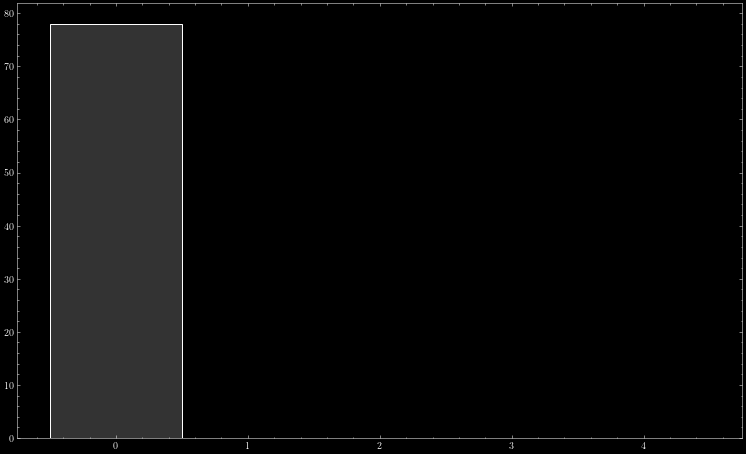

In [537]:
fig, ax = plt.subplots(1, 1, figsize=(13,8))
plt.hist(tadnorms, bins=np.arange(-0.5, max(tadnorms)+5), color='0.2', edgecolor='w')
plt.show()

### Gauge group rank

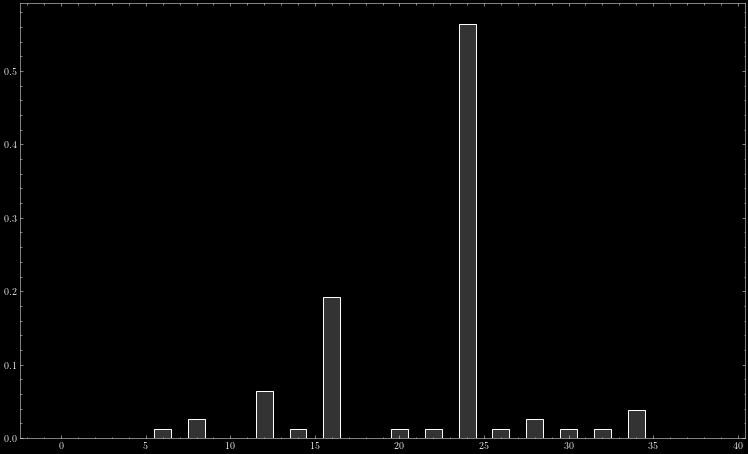

In [536]:
fig, ax = plt.subplots(1, 1, figsize=(13,8))
plt.hist(ranks, bins=np.arange(-0.5, max(ranks)+5), density=True, color='0.2', edgecolor='w')
plt.show()

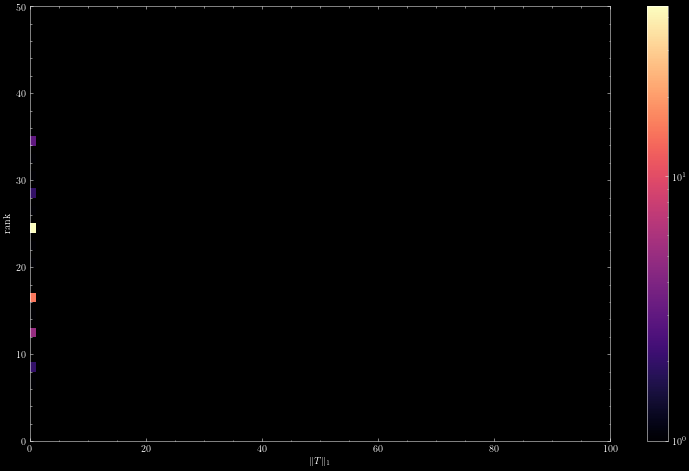

In [494]:
mask = (kList > 0)

fig, ax = plt.subplots(1, 1, figsize=(13,8))
im = plt.hist2d(tadnorms[mask], ranks[mask], bins=[np.arange(101), np.arange(51)], cmap='magma', norm=colors.LogNorm())
plt.colorbar(im[3])
plt.xlabel(r'$\|T\|_1$')
plt.ylabel('rank')
plt.show()

## Optimization

### Tadpole/SUSY scales

In [631]:
files = glob.glob('models_optimization_tad_susy/*/*/*.npy')
models = [np.load(f) for f in files]
metaData = np.array([f.split('\\')[-1].split('_') for f in files])

tadScaleList = [int(a[-3][4:]) for a in metaData]
susyScaleList = [int(a[-2][4:]) for a in metaData]

tadScales = np.unique(tadScaleList)
susyScales = np.unique(susyScaleList)

In [632]:
TKScounts = np.zeros([len(tadScales), len(susyScales)], dtype='int')

for i in range(len(tadScales)):
    for j in range(len(susyScales)):
        whr = np.where((tadScaleList == tadScales[i]) * (susyScaleList == susyScales[j]))[0]
        
        for w in whr:
            TKScounts[i,j] += len(models[w])

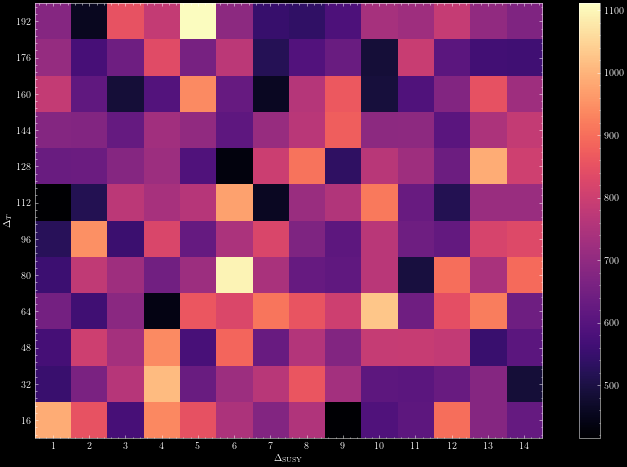

In [633]:
fig, ax = plt.subplots(1, 1, figsize=(13,8))
im = plt.imshow(TKScounts, origin='lower', cmap='magma')
plt.colorbar(im)

plt.xticks(range(len(susyScales)), labels=susyScales)
plt.yticks(range(len(tadScales)), labels=tadScales)
plt.xlabel(r'$\Delta_\text{SUSY}$')
plt.ylabel(r'$\Delta_T$')
plt.show()

## Optimization (old)

### Scales

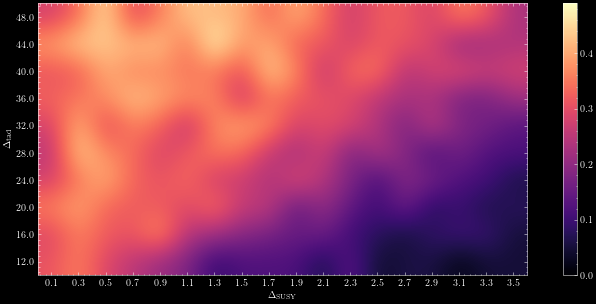

In [4]:
# files = glob.glob('condor/tad_susy_scales_v1/*/*.npy')
files = glob.glob('condor/tad_susy_scales_v2/*/*.npy')

tadScaleList = np.array([int(f[141:144])/10 for f in files])
susyScaleList = np.array([int(f[150:152])/10 for f in files])

successCounts = np.array([np.load(f) for f in files])

tadScales = np.unique(tadScaleList)
susyScales = np.unique(susyScaleList)

counts = np.zeros([len(tadScales), len(susyScales), 2])

for i in range(len(tadScales)):
    for j in range(len(susyScales)):
        whr = np.where((tadScaleList == tadScales[i]) * (susyScaleList == susyScales[j]))[0]
        counts[i,j] = np.sum(successCounts[whr], axis=0)

probs = counts[:,:,0] / (counts[:,:,0] + counts[:,:,1])

fig, ax = plt.subplots(1, 1, figsize=(13,5))
im = plt.imshow(probs, origin='lower', cmap='magma', interpolation='bicubic', vmin=0)
plt.colorbar(im)
plt.yticks(range(len(tadScales)), labels=tadScales)
plt.xticks(range(len(susyScales)), labels=susyScales)
plt.xlabel(r'$\Delta_\text{SUSY}$')
plt.ylabel(r'$\Delta_\text{tad}$')

# plt.savefig('scales_v1.png')
# plt.savefig('scales_v2.png')

plt.show()

### Weights & tadscale

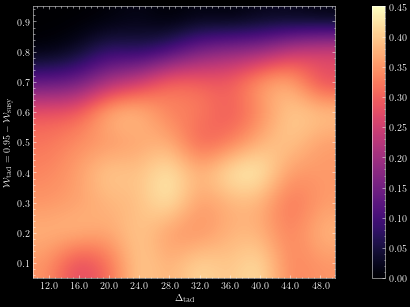

In [5]:
files = glob.glob('condor/weights_tadscale_v1/*/*.npy')

tadWeightList = np.array([int(f[128:131])/100 for f in files])
tadScaleList = np.array([int(f[142:145])/10 for f in files])

successCounts = np.array([np.load(f) for f in files])

tadWeights = np.unique(tadWeightList)
tadScales = np.unique(tadScaleList)

counts = np.zeros([len(tadWeights), len(tadScales), 2])

for i in range(len(tadWeights)):
    for j in range(len(tadScales)):
        whr = np.where((tadWeightList == tadWeights[i]) * (tadScaleList == tadScales[j]))[0]
        counts[i,j] = np.sum(successCounts[whr], axis=0)

probs = counts[:,:,0] / (counts[:,:,0] + counts[:,:,1])

fig, ax = plt.subplots(1, 1, figsize=(13,5))
im = plt.imshow(probs, origin='lower', cmap='magma', interpolation='bicubic', vmin=0)
plt.colorbar(im)
plt.yticks(range(len(tadWeights)), labels=tadWeights)
plt.xticks(range(len(tadScales)), labels=tadScales)
plt.xlabel(r'$\Delta_\text{tad}$')
plt.ylabel(r'$\mathcal{W}_\text{tad}=0.95-\mathcal{W}_\text{susy}$')

# plt.savefig('weights_scales_v1.png')

plt.show()

### Cross-over probabilities
These are parametrized by $x,y,c\in[0,1]$ as

|Method<img width=100/>|probability <img width=200/>|
|---|---|
|stack | $(1-c)\cos^2{(\frac{\pi}{2}x)}\cos^2{(\frac{\pi}{2}y)}$ |
|stack (const) | $(1-c)\sin^2{(\frac{\pi}{2}x)}\cos^2{(\frac{\pi}{2}y)}$ |
|gene| $(1-c)\cos^2{(\frac{\pi}{2}x)}\sin^2{(\frac{\pi}{2}y)}$ |
|gene (const)| $(1-c)\sin^2{(\frac{\pi}{2}x)}\sin^2{(\frac{\pi}{2}y)}$ |
|clone| $c$ |

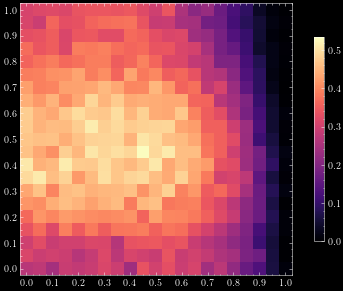

In [10]:
files = glob.glob('condor/pxo_xycparam_v3/*/*.npy')

xList = [int(f[56:59])/100 for f in files]
yList = [int(f[62:65])/100 for f in files]
cList = [int(f[68:70])/100 for f in files]

successCounts = np.array([np.load(f) for f in files])

xx = np.unique(xList)
yy = np.unique(yList)
cc = np.unique(cList)

counts = np.zeros([len(xx), len(yy), len(cc), 2])

for i in range(len(xx)):
    for j in range(len(yy)):
        for k in range(len(cc)):
            whr = np.where((xList == xx[i]) * (yList == yy[j]) * (cList == cc[k]))[0]
            counts[i,j,k] = np.sum(successCounts[whr], axis=0)

probs = counts[:,:,:,0] / (counts[:,:,:,0] + counts[:,:,:,1])

if len(cc) > 1:
    fig, ax = plt.subplots(1, len(cc), figsize=(15,5), sharex=True, sharey=True)

    for i in range(len(cc)):
        im = ax[i].imshow(probs[:,:,i].T, origin='lower', cmap='magma', interpolation='none', vmin=0)
        ax[i].set_title('c = %.2f' % cc[i])
else:
    fig, ax = plt.subplots(1, 1, figsize=(8,5))
    im = ax.imshow(probs[:,:,0].T, origin='lower', cmap='magma', interpolation='none', vmin=0)

plt.colorbar(im, ax=ax, shrink=0.75)
plt.xticks(np.arange(0,len(xx),2), labels=xx[::2])
plt.yticks(np.arange(0,len(yy),2), labels=yy[::2])

# plt.savefig('pxo_xycparam_v1.png')

plt.show()

### Mutations

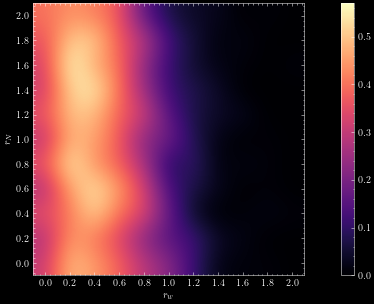

In [68]:
files = glob.glob('condor/mutPM_v1/*/*.npy')

NaPMList = np.array([int(f[102:105])/100 for f in files])
windPMList = np.array([int(f[105:108])/100 for f in files])

successCounts = np.array([np.load(f) for f in files])

NaPMs = np.unique(NaPMList)
windPMs = np.unique(windPMList)

counts = np.zeros([len(NaPMs), len(windPMs), 2])

for i in range(len(NaPMs)):
    for j in range(len(windPMs)):
        whr = np.where((NaPMList == NaPMs[i]) * (windPMList == windPMs[j]))[0]
        counts[i,j] = np.sum(successCounts[whr], axis=0)

probs = counts[:,:,0] / (counts[:,:,0] + counts[:,:,1])

fig, ax = plt.subplots(1, 1, figsize=(13,5))
im = plt.imshow(probs, origin='lower', cmap='magma', interpolation='bicubic', vmin=0)
plt.colorbar(im)
plt.yticks(range(len(NaPMs)), labels=NaPMs)
plt.xticks(range(len(windPMs)), labels=windPMs)
plt.xlabel(r'$r_w$')
plt.ylabel(r'$r_N$')

# plt.savefig('weights_scales_v1.png')

plt.show()

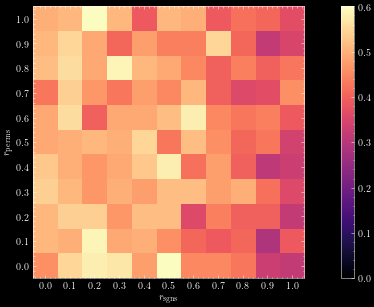

In [93]:
files = glob.glob('condor/wind_perm_sgns_v1/*/*.npy')

permList = np.array([int(f[117:120])/100 for f in files])
sgnsList = np.array([int(f[120:123])/100 for f in files])

successCounts = np.array([np.load(f) for f in files])

perms = np.unique(permList)
sgns = np.unique(sgnsList)

counts = np.zeros([len(perms), len(sgns), 2])

for i in range(len(perms)):
    for j in range(len(sgns)):
        whr = np.where((permList == perms[i]) * (sgnsList == sgns[j]))[0]
        counts[i,j] = np.sum(successCounts[whr], axis=0)

probs = counts[:,:,0] / (counts[:,:,0] + counts[:,:,1])

fig, ax = plt.subplots(1, 1, figsize=(13,5))
im = plt.imshow(probs, origin='lower', cmap='magma', interpolation='none', vmin=0)
plt.colorbar(im)
plt.yticks(range(len(perms)), labels=perms)
plt.xticks(range(len(sgns)), labels=sgns)
plt.xlabel(r'$r_\text{sgns}$')
plt.ylabel(r'$r_\text{perms}$')

# plt.savefig('weights_scales_v1.png')

plt.show()

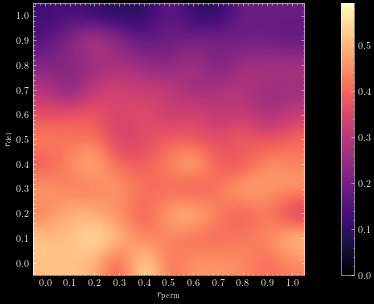

In [105]:
files = glob.glob('condor/stckmut_del_perm_v1/*/*.npy')

delList = np.array([int(f[107:110])/100 for f in files])
permList = np.array([int(f[110:113])/100 for f in files])

successCounts = np.array([np.load(f) for f in files])

dels = np.unique(delList)
perms = np.unique(permList)

counts = np.zeros([len(dels), len(perms), 2])

for i in range(len(dels)):
    for j in range(len(perms)):
        whr = np.where((delList == dels[i]) * (permList == perms[j]))[0]
        counts[i,j] = np.sum(successCounts[whr], axis=0)

probs = counts[:,:,0] / (counts[:,:,0] + counts[:,:,1])

fig, ax = plt.subplots(1, 1, figsize=(13,5))
im = plt.imshow(probs, origin='lower', cmap='magma', interpolation='bicubic', vmin=0)
plt.colorbar(im)
plt.yticks(range(len(dels)), labels=dels)
plt.xticks(range(len(perms)), labels=perms)
plt.xlabel(r'$r_\text{perm}$')
plt.ylabel(r'$r_\text{del}$')

# plt.savefig('weights_scales_v1.png')

plt.show()

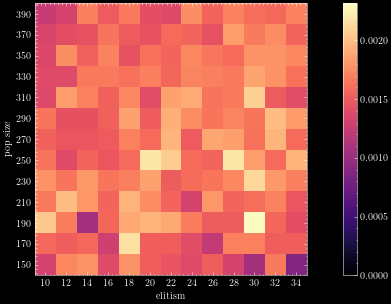

In [8]:
files = glob.glob('condor/popsize_elite_v2/*/*.npy')

popsizeList = np.array([int(f[59:62]) for f in files])
eliteList = np.array([int(f[62:64]) for f in files])

successCounts = np.array([np.load(f) for f in files])

sizes = np.unique(popsizeList)
elites = np.unique(eliteList)

counts = np.zeros([len(sizes), len(elites), 2])

for i in range(len(sizes)):
    for j in range(len(elites)):
        whr = np.where((popsizeList == sizes[i]) * (eliteList == elites[j]))[0]
        counts[i,j] = np.sum(successCounts[whr], axis=0)

probs = counts[:,:,0] / (counts[:,:,0] + counts[:,:,1])
for i in range(len(sizes)):
    probs[i] /= sizes[i]

fig, ax = plt.subplots(1, 1, figsize=(13,5))
im = plt.imshow(probs, origin='lower', cmap='magma', interpolation='none', vmin=0)
plt.colorbar(im)
plt.yticks(range(len(sizes)), labels=sizes)
plt.xticks(range(len(elites)), labels=elites)
plt.xlabel('elitism')
plt.ylabel('pop size')

# plt.savefig('weights_scales_v1.png')

plt.show()

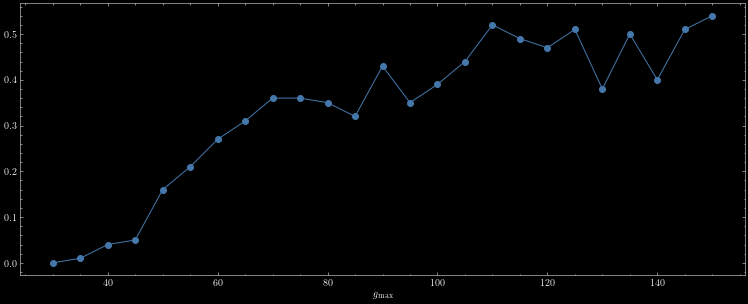

In [20]:
files = glob.glob('condor/gmax_v1/*/*.npy')

gmaxList = np.array([int(f[52:55]) for f in files])

successCounts = np.array([np.load(f) for f in files])

gmaxes = np.unique(gmaxList)

counts = np.zeros([len(gmaxes), 2])

for i in range(len(gmaxes)):
    whr = np.where(gmaxList == gmaxes[i])[0]
    counts[i] = np.sum(successCounts[whr], axis=0)

probs = counts[:,0] / (counts[:,0] + counts[:,1])

fig, ax = plt.subplots(1, 1, figsize=(13,5))
plt.plot(gmaxes, probs, '-o')
plt.xlabel(r'$g_\text{max}$')

# plt.savefig('weights_scales_v1.png')

plt.show()